y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
# unique: 12
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
# unique: 3
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
# unique: 4
default
no     44396
yes      815
Name: count, dtype: int64
# unique: 2
housing
yes    25130
no     20081
Name: count, dtype: int64
# unique: 2
loan
no     37967
yes     7244
Name: count, dtype: int64
# unique: 2
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64
# unique: 3
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
fe

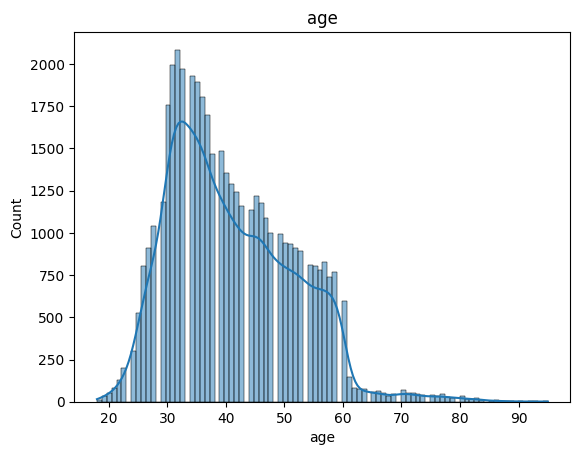

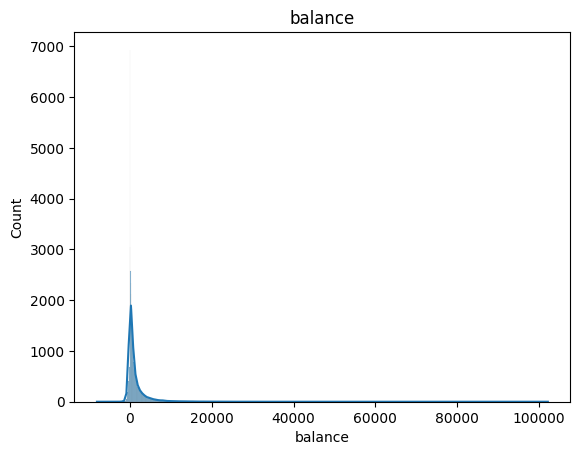

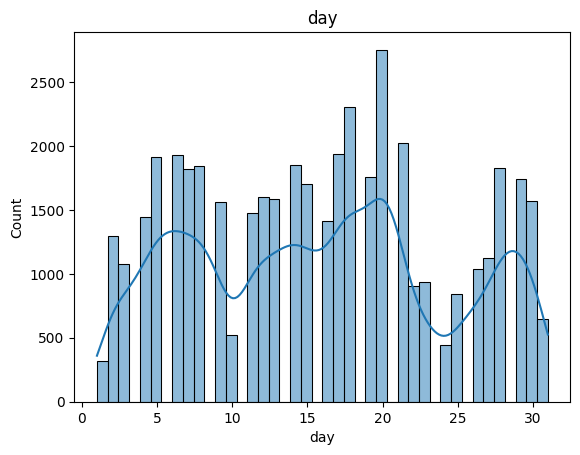

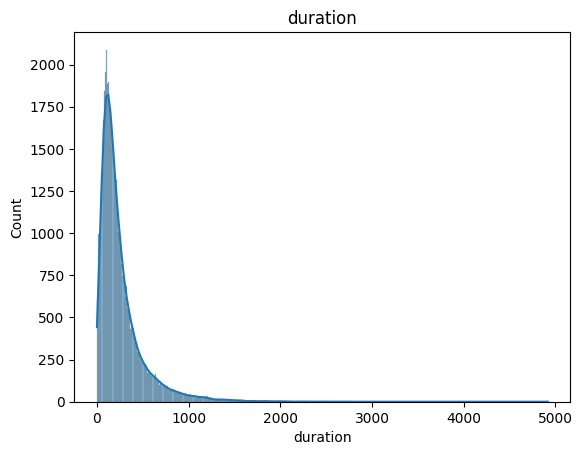

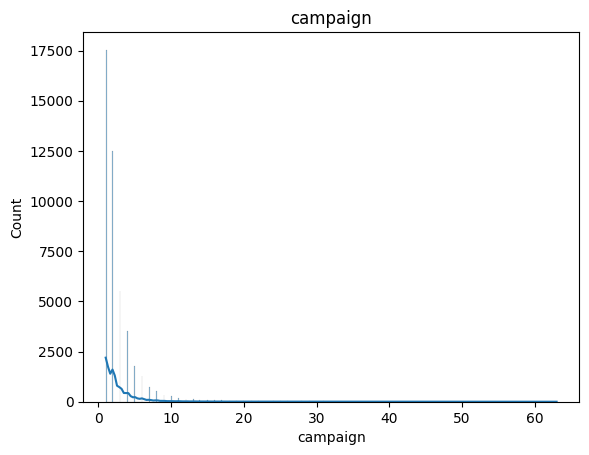

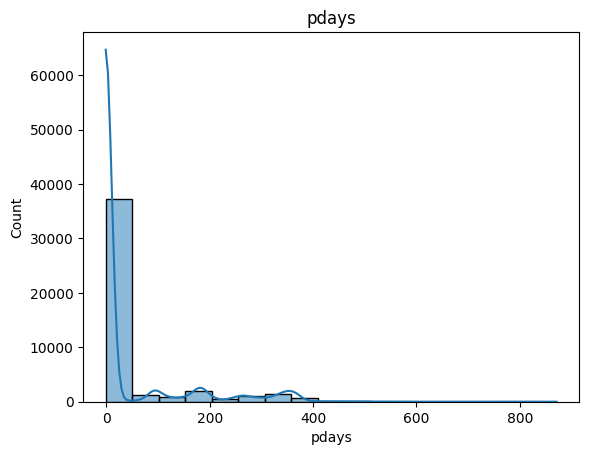

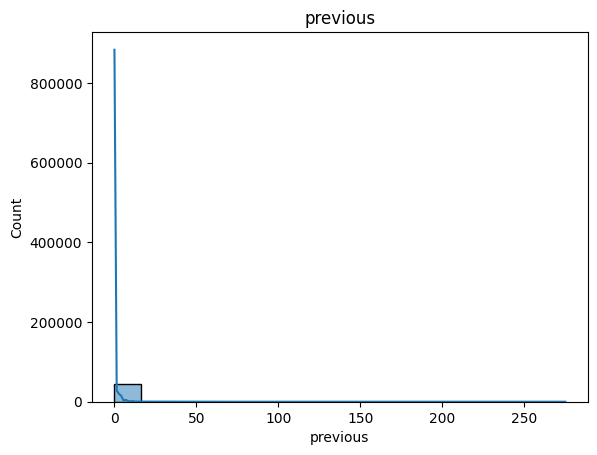

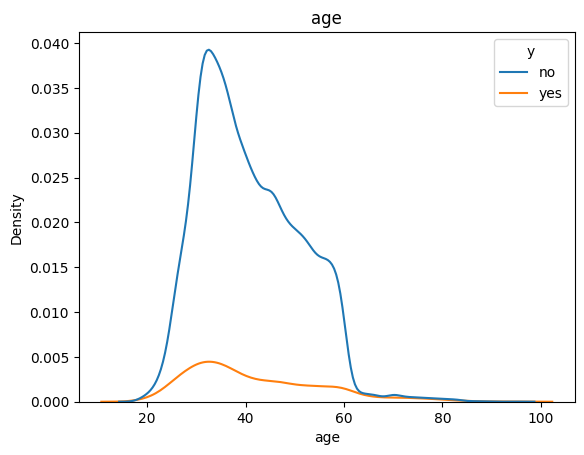

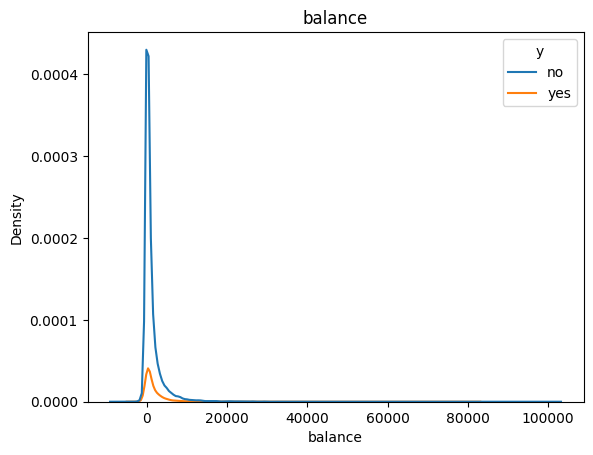

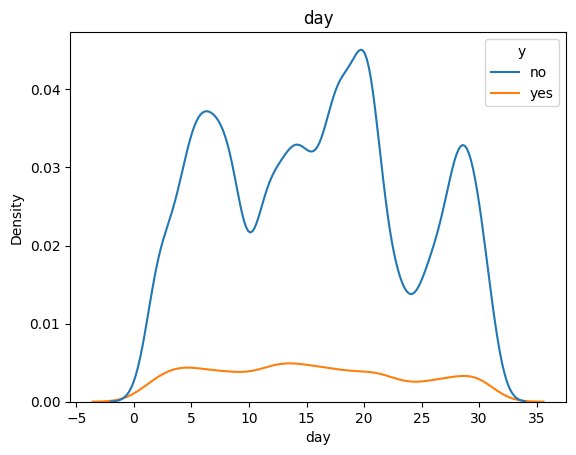

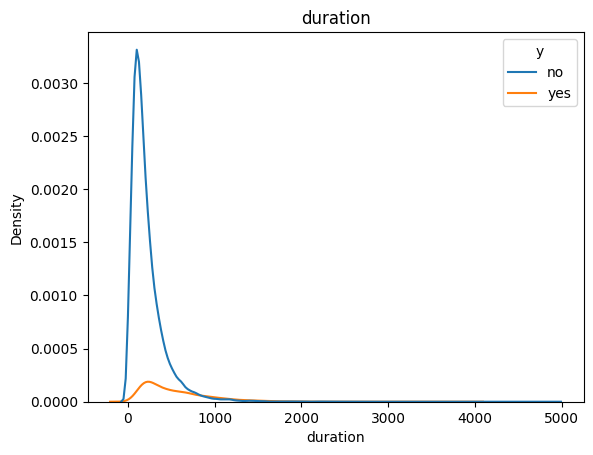

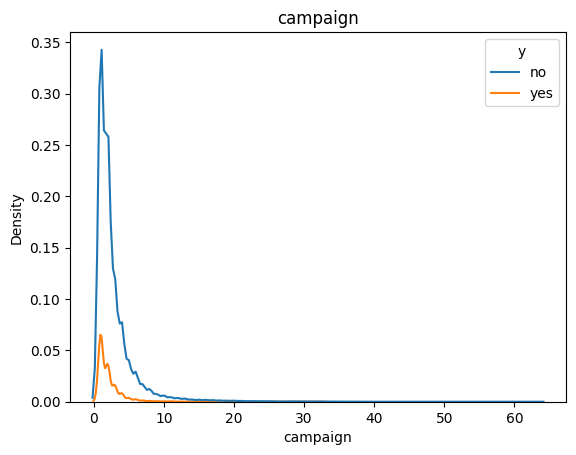

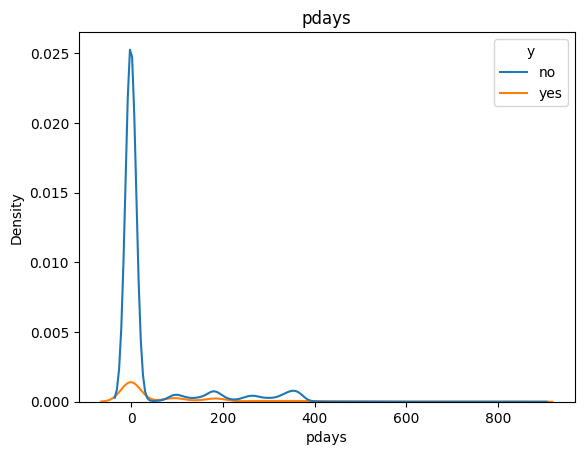

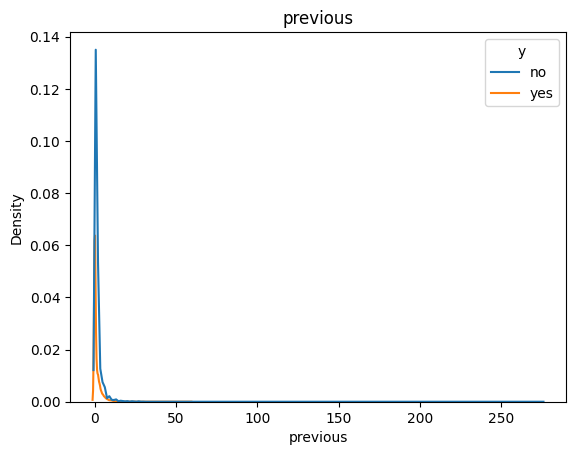

In [2]:
# Preprocessing / Data Exploration

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# load
df = pd.read_csv("bank-full.csv", sep=";")

# count value of y
print(df["y"].value_counts(normalize=True))

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(df[col].value_counts())
    print(f"# unique: {df[col].nunique()}")

num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()


for col in num_cols:
    plt.figure()
    sns.kdeplot(data=df, x=col, hue="y")
    plt.title(col)
    plt.show()

In [ ]:
num_cols = df.select_dtypes(include="number").columns

summary = df[num_cols].agg([
    "mean", "median", "std", "min", "max"
]).T

summary["skew"] = df[num_cols].skew()
summary["iqr"] = df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)

summary



,mean,median,std,min,max,skew,iqr
age,40.936210,39.0,10.618762,18.0,95.0,0.684818,15.0
balance,1362.272058,448.0,3044.765829,-8019.0,102127.0,8.360308,1356.0
day,15.806419,16.0,8.322476,1.0,31.0,0.093079,13.0
duration,258.163080,180.0,257.527812,0.0,4918.0,3.144318,216.0
campaign,2.763841,2.0,3.098021,1.0,63.0,4.898650,2.0
pdays,40.197828,-1.0,100.128746,-1.0,871.0,2.615715,0.0
previous,0.580323,0.0,2.303441,0.0,275.0,41.846454,0.0


In [ ]:
group_stats = df.groupby("y")[num_cols].agg(["mean", "median"])
group_stats

age             balance               day           duration  \
          mean median         mean median       mean median        mean   
y                                                                         
no   40.838986   39.0  1303.714969  417.0  15.892290   16.0  221.182806   
yes  41.670070   38.0  1804.267915  733.0  15.158253   15.0  537.294574   

            campaign             pdays         previous         
    median      mean median       mean median      mean median  
y                                                               
no   164.0  2.846350    2.0  36.421372   -1.0  0.502154    0.0  
yes  426.0  2.141047    2.0  68.702968   -1.0  1.170354    0.0

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# target
y = (df["y"] == "yes").astype(int)
X = df.drop(columns=["y"])

# drop leakage
X = X.drop(columns=["duration"])

# pdays fix
X["pdays_contacted"] = (X["pdays"] != -1).astype(int)
X["pdays"] = X["pdays"].replace(-1, np.nan)

# balance fix
X["balance_negative"] = (X["balance"] < 0).astype(int)
X["balance"] = np.log1p(X["balance"].clip(lower=0))

# perform log transform
for col in ["campaign", "previous"]:
    X[col] = np.log1p(X[col])


# SPLIT (IMPORTANT FIRST)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [4]:
# Necessary Modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from xgboost import XGBClassifier, plot_importance

In [5]:
# Further Preprocessing:

# identify columns from TRAIN only
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# preprocessing
numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_preprocessor, num_cols),
    ("cat", categorical_preprocessor, cat_cols)
])

# fit ONLY on train
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)


In [6]:
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric=["logloss", "auc"],
    learning_rate=0.1,
    n_estimators=500,
    max_depth=4,
    subsample=0.5,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    tree_method="hist",
    early_stopping_rounds=20
)

# Adjusted max_depth, subsample, and reg_alpha independently to test out

xgb_base.fit(
    X_train_proc,
    y_train,
    eval_set=[(X_train_proc, y_train), (X_val_proc, y_val)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=20,
              enable_categorical=False, eval_metric=['logloss', 'auc'],
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

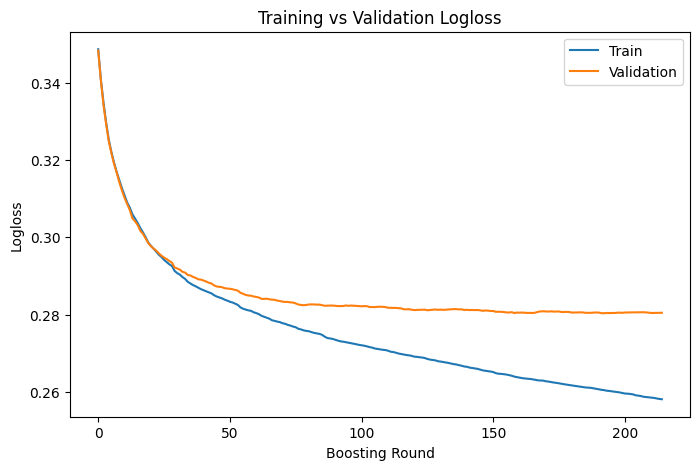

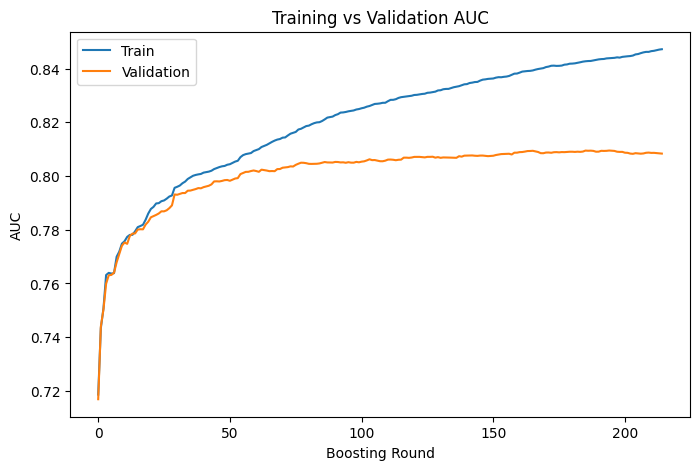

Validation Accuracy: 0.8947213211442052
Validation F1: 0.3473491773308958
Validation ROC-AUC: 0.809486836813846
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      5988
           1       0.63      0.24      0.35       794

    accuracy                           0.89      6782
   macro avg       0.77      0.61      0.65      6782
weighted avg       0.87      0.89      0.87      6782



<Figure size 1000x800 with 0 Axes>

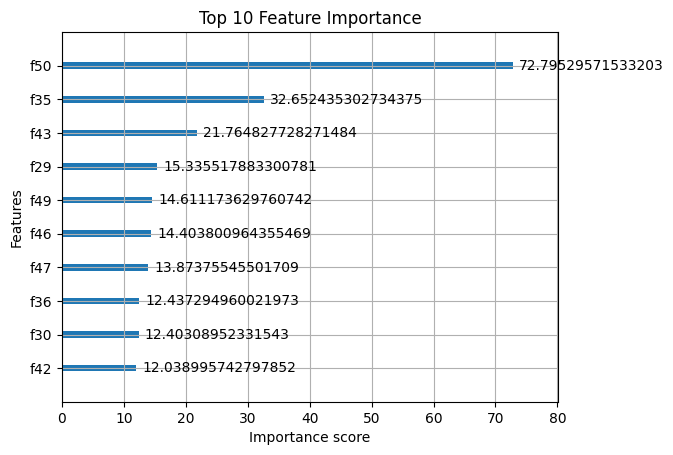

,feature,importance
50,cat__poutcome_success,0.159984
35,cat__contact_unknown,0.071761
43,cat__month_mar,0.047833
29,cat__housing_no,0.033703
49,cat__poutcome_other,0.032111
46,cat__month_oct,0.031656
47,cat__month_sep,0.030491
36,cat__month_apr,0.027334
30,cat__housing_yes,0.027259
42,cat__month_jun,0.026458


In [7]:
# Plot training & Validation Performance

results = xgb_base.evals_result()

# Logloss
plt.figure(figsize=(8, 5))
plt.plot(results["validation_0"]["logloss"], label="Train")
plt.plot(results["validation_1"]["logloss"], label="Validation")
plt.xlabel("Boosting Round")
plt.ylabel("Logloss")
plt.title("Training vs Validation Logloss")
plt.legend()
plt.show()

# AUC
plt.figure(figsize=(8, 5))
plt.plot(results["validation_0"]["auc"], label="Train")
plt.plot(results["validation_1"]["auc"], label="Validation")
plt.xlabel("Boosting Round")
plt.ylabel("AUC")
plt.title("Training vs Validation AUC")
plt.legend()
plt.show()


val_pred = xgb_base.predict(X_val_proc)
val_prob = xgb_base.predict_proba(X_val_proc)[:, 1]

print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Validation F1:", f1_score(y_val, val_pred))
print("Validation ROC-AUC:", roc_auc_score(y_val, val_prob))
print(classification_report(y_val, val_pred))

plt.figure(figsize=(10, 8))
plot_importance(xgb_base, max_num_features=10, importance_type="gain")
plt.title("Top 10 Feature Importance")
plt.show()


# get feature names
feature_names = preprocessor.get_feature_names_out()

# get importance
importances = xgb_base.feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_imp.head(10)

In [8]:
learning_rates = [0.01, 0.1, 0.3]
lr_results = []

for lr in learning_rates:
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric=["logloss", "auc"],
        learning_rate=lr,
        n_estimators=500,
        max_depth=4,
        subsample=0.5,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        tree_method="hist",
        early_stopping_rounds=20
    )

    model.fit(
        X_train_proc,
        y_train,
        eval_set=[(X_train_proc, y_train), (X_val_proc, y_val)],
        verbose=False
    )

    val_pred = model.predict(X_val_proc)
    val_prob = model.predict_proba(X_val_proc)[:, 1]

    lr_results.append({
        "learning_rate": lr,
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_f1": f1_score(y_val, val_pred),
        "val_roc_auc": roc_auc_score(y_val, val_prob),
        "best_iteration": getattr(model, "best_iteration", None)
    })

lr_df = pd.DataFrame(lr_results)
print(lr_df)

   learning_rate  val_accuracy    val_f1  val_roc_auc  best_iteration
0           0.01      0.895901  0.292585     0.800768             498
1           0.10      0.894721  0.347349     0.809487             194
2           0.30      0.894721  0.355596     0.801834              62


In [10]:
from sklearn.preprocessing import StandardScaler

# fit on TRAIN ONLY
scaler = StandardScaler(with_mean=False)  # sparse safe

X_train_mlp = scaler.fit_transform(X_train_proc)
X_val_mlp = scaler.transform(X_val_proc)
X_test_mlp = scaler.transform(X_test_proc)

In [15]:
from sklearn.neural_network import MLPClassifier

def train_mlp(
    X_train, y_train,
    hidden_layer_sizes=(64,),
    activation="relu",
    learning_rate_init=0.01,
    max_iter=400
):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        learning_rate_init=learning_rate_init,
        max_iter=max_iter,
        random_state=42
    )

    model.fit(X_train, y_train)
    return model


mlp_base = train_mlp(
    X_train_mlp, y_train,
    hidden_layer_sizes=(64,),
    activation="relu",
    learning_rate_init=0.01,
    max_iter=200
)

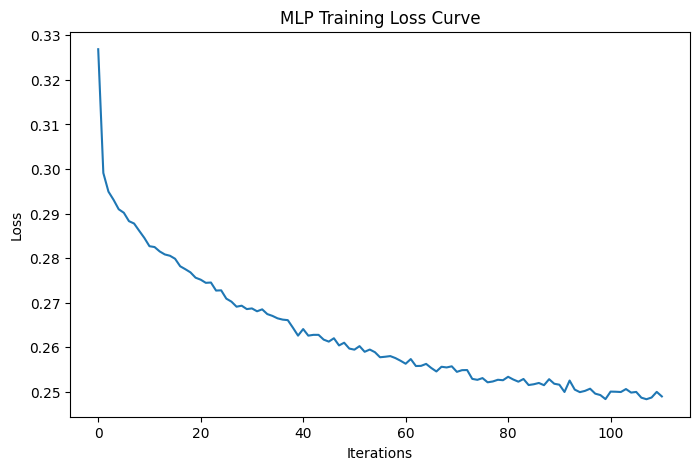

Validation Accuracy: 0.8841049837805957
Validation F1: 0.3188908145580589
Validation ROC-AUC: 0.7442971585488357


In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(mlp_base.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve")
plt.show()

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

val_pred = mlp_base.predict(X_val_mlp)
val_prob = mlp_base.predict_proba(X_val_mlp)[:, 1]

print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Validation F1:", f1_score(y_val, val_pred))
print("Validation ROC-AUC:", roc_auc_score(y_val, val_prob))

In [11]:
# Network Size Experiment

architectures = [
    (64,),
    (128, 64),
    (256, 128, 64)
]

arch_results = []

for arch in architectures:
    model = train_mlp(
        X_train_mlp, y_train,
        hidden_layer_sizes=arch,
        activation="relu",
        learning_rate_init=0.01
    )

    val_pred = model.predict(X_val_mlp)
    val_prob = model.predict_proba(X_val_mlp)[:, 1]

    arch_results.append({
        "architecture": str(arch),
        "F1": f1_score(y_val, val_pred),
        "ROC_AUC": roc_auc_score(y_val, val_prob)
    })

pd.DataFrame(arch_results)



,architecture,F1,ROC_AUC
0,"(64,)",0.318891,0.744297
1,"(128, 64)",0.349108,0.681554
2,"(256, 128, 64)",0.331115,0.695354


In [12]:
# Activation Function Experiment

activations = ["relu", "tanh"]
act_results = []

for act in activations:
    model = train_mlp(
        X_train_mlp, y_train,
        hidden_layer_sizes=(128, 64),
        activation=act,
        learning_rate_init=0.01
    )

    val_pred = model.predict(X_val_mlp)
    val_prob = model.predict_proba(X_val_mlp)[:, 1]

    act_results.append({
        "activation": act,
        "F1": f1_score(y_val, val_pred),
        "ROC_AUC": roc_auc_score(y_val, val_prob)
    })

pd.DataFrame(act_results)

,activation,F1,ROC_AUC
0,relu,0.349108,0.681554
1,tanh,0.395539,0.735962


In [1]:
# Learning Rate Experiment

learning_rates = [0.001, 0.01, 0.1]
lr_results = []

for lr in learning_rates:
    model = train_mlp(
        X_train_mlp, y_train,
        hidden_layer_sizes=(128, 64),
        activation="relu",
        learning_rate_init=lr
    )

    val_pred = model.predict(X_val_mlp)
    val_prob = model.predict_proba(X_val_mlp)[:, 1]

    lr_results.append({
        "learning_rate": lr,
        "F1": f1_score(y_val, val_pred),
        "ROC_AUC": roc_auc_score(y_val, val_prob)
    })

pd.DataFrame(lr_results)


NameError: name 'train_mlp' is not defined

In [14]:
iters = [100, 200, 400]
iter_results = []

for it in iters:
    model = train_mlp(
        X_train_mlp, y_train,
        hidden_layer_sizes=(128, 64),
        max_iter=it
    )

    val_pred = model.predict(X_val_mlp)
    val_prob = model.predict_proba(X_val_mlp)[:, 1]

    iter_results.append({
        "max_iter": it,
        "F1": f1_score(y_val, val_pred),
        "ROC_AUC": roc_auc_score(y_val, val_prob)
    })

pd.DataFrame(iter_results)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,max_iter,F1,ROC_AUC
0,100,0.316570,0.691932
1,200,0.349108,0.681554
2,400,0.349108,0.681554


In [17]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score
)
import pandas as pd

def evaluate_model(model, X, y, name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1": f1_score(y, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y, y_prob),
        "AUC_PR": average_precision_score(y, y_prob)
    }

comparison_df = pd.DataFrame([
    evaluate_model(xgb_base, X_test_proc, y_test, "GBDT"),
    evaluate_model(mlp_base, X_test_mlp, y_test, "MLP")
])

print(comparison_df)

  Model  Accuracy  Precision    Recall        F1   ROC_AUC    AUC_PR
0  GBDT  0.898260   0.658462  0.269861  0.382826  0.797295  0.464793
1   MLP  0.888381   0.552326  0.239596  0.334213  0.744105  0.365107


In [18]:
import time

start = time.time()
xgb_base.fit(
    X_train_proc, y_train,
    eval_set=[(X_train_proc, y_train), (X_val_proc, y_val)],
    verbose=False
)
xgb_time = time.time() - start

start = time.time()
mlp_base.fit(X_train_mlp, y_train)
mlp_time = time.time() - start

print("XGB training time:", xgb_time)
print("MLP training time:", mlp_time)

XGB training time: 15.486279487609863
MLP training time: 27.294361114501953
